SVM Text Classification – Phân loại tin tức tiếng Việt
> Pipeline hoàn chỉnh: Load → EDA → Preprocessing (underthesea) → TF-IDF → SVM → Evaluate → Save

## 0. Cài thư viện

In [ ]:
!pip install underthesea scikit-learn matplotlib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.7 MB/s eta 0:00:00


## 1. Import

In [ ]:
import os, re, ast, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
tqdm.pandas()

from underthesea import word_tokenize

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
import joblib

print('Import OK')

Import OK


## 2. Load & Chuẩn hoá cột

In [ ]:
DATA_PATH = '/content/merged_file (1).csv'
df_raw = pd.read_csv(DATA_PATH, on_bad_lines='skip')
print('Raw shape:', df_raw.shape)
df_raw.head(3)

Raw shape: (6474, 7)


,category,date,title,description,text,author,url
0,bất động sản,"Chủ nhật, 19/10/2025, 10:09 (GMT+7)",Giá đất Cần Giờ tăng gấp 2-3 lần sau một năm,Hiệu ứng từ Khu đô thị lấn biển Cần Giờ khởi c...,"Chị Trần Thị Quế, một nhà đầu tư nhỏ lẻ, cho b...",Phương Uyên,https://vnexpress.net/gia-dat-can-gio-tang-gap...
1,tâm sự,"Thứ hai, 6/4/2026, 13:00 (GMT+7)","Bạn trai chuẩn bị mì tôm, xúc xích khi đi du l...","Những điểm tham quan vẫn đi đầy đủ, chỉ là mọi...","Tôi và bạn trai quen nhau gần hai năm, cả hai ...",Diệu Linh,https://vnexpress.net/tiet-kiem-ban-trai-chuan...
2,sức khỏe,"Thứ tư, 6/5/2026, 09:00 (GMT+7)","Phân biệt sốc nhiệt với bệnh hô hấp, tiêu hóa ...","Cùng gia tăng trong mùa nắng nóng, sốc nhiệt x...",Nội dung: Huệ Lan Thiết kế: Thái Hưng Hệ thống...,Vaccine tay chân miệng đã được Bộ Y tế phê duy...,https://vnexpress.net/phan-biet-soc-nhiet-voi-...


In [ ]:
def standardize_columns(df_raw):
    lower_map = {c.lower(): c for c in df_raw.columns}
    alias_candidates = {
        'title': ['title'],
        'summary': ['description'],
        'content': ['text'],
        'category': ['category'],
        'author': ['author'],
        'url': ['url'],
        'published_date': ['date']
    }
    rename_map = {}
    for standard_col, aliases in alias_candidates.items():
        for alias in aliases:
            if alias in lower_map:
                rename_map[lower_map[alias]] = standard_col
                break
    df = df_raw.rename(columns=rename_map).copy()
    for col in ['title', 'summary', 'content', 'category', 'author', 'url', 'published_date']:
        if col not in df.columns:
            df[col] = np.nan
    return df

df = standardize_columns(df_raw)
print('Standardized shape:', df.shape)
df.head(3)

Standardized shape: (6474, 7)


,category,published_date,title,summary,content,author,url
0,bất động sản,"Chủ nhật, 19/10/2025, 10:09 (GMT+7)",Giá đất Cần Giờ tăng gấp 2-3 lần sau một năm,Hiệu ứng từ Khu đô thị lấn biển Cần Giờ khởi c...,"Chị Trần Thị Quế, một nhà đầu tư nhỏ lẻ, cho b...",Phương Uyên,https://vnexpress.net/gia-dat-can-gio-tang-gap...
1,tâm sự,"Thứ hai, 6/4/2026, 13:00 (GMT+7)","Bạn trai chuẩn bị mì tôm, xúc xích khi đi du l...","Những điểm tham quan vẫn đi đầy đủ, chỉ là mọi...","Tôi và bạn trai quen nhau gần hai năm, cả hai ...",Diệu Linh,https://vnexpress.net/tiet-kiem-ban-trai-chuan...
2,sức khỏe,"Thứ tư, 6/5/2026, 09:00 (GMT+7)","Phân biệt sốc nhiệt với bệnh hô hấp, tiêu hóa ...","Cùng gia tăng trong mùa nắng nóng, sốc nhiệt x...",Nội dung: Huệ Lan Thiết kế: Thái Hưng Hệ thống...,Vaccine tay chân miệng đã được Bộ Y tế phê duy...,https://vnexpress.net/phan-biet-soc-nhiet-voi-...


## 3. EDA

In [ ]:
def clean_basic_text(x):
    if pd.isna(x): return ''
    return re.sub(r'\s+', ' ', str(x)).strip()

for col in ['title', 'summary', 'content']:
    df[col] = df[col].fillna('').astype(str).apply(clean_basic_text)
df['category'] = df['category'].fillna('').astype(str).str.strip()

before = len(df)
if df['url'].notna().any():
    df = df.drop_duplicates(subset=['url'])
df = df.drop_duplicates(subset=['title', 'summary'])
df = df[df['category'] != '']
full_text = (df['title'] + ' ' + df['content']).str.strip()
df = df[full_text.str.len() > 30].reset_index(drop=True)

print(f'Before clean: {before:,} | After clean: {len(df):,}')
print('\nTop categories:')
display(df['category'].value_counts().head(20))

Before clean: 6,474 | After clean: 6,428

Top categories:


,count
category,
góc nhìn,1776
bất động sản,1330
xe,965
thời sự,556
giáo dục,531
pháp luật,292
khoa học công nghệ,285
sức khỏe,227
thể thao,180


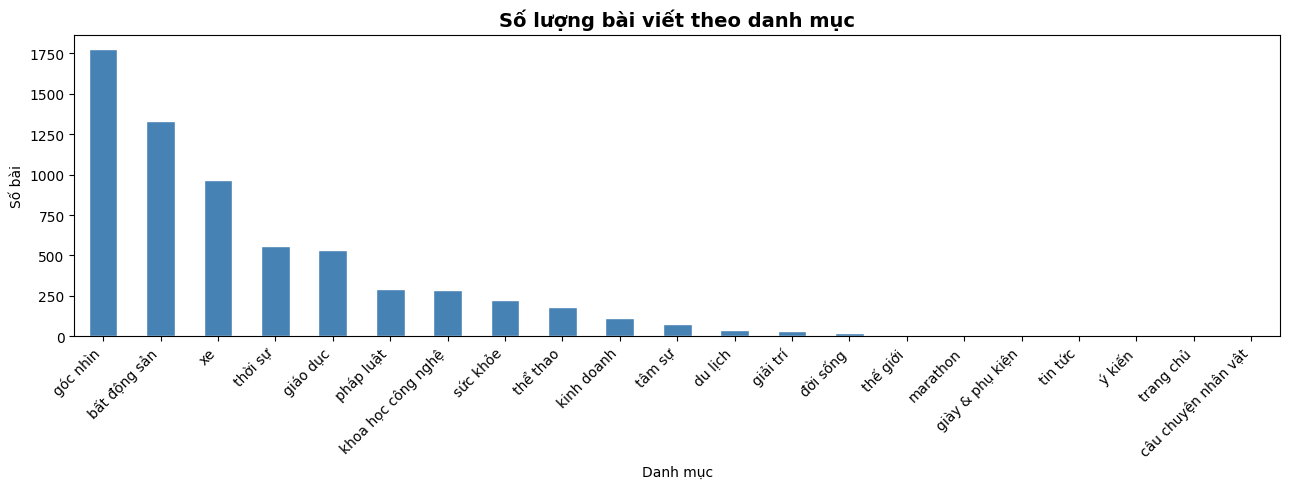

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))
df['category'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Số lượng bài viết theo danh mục', fontsize=14, fontweight='bold')
ax.set_xlabel('Danh mục')
ax.set_ylabel('Số bài')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Tiền xử lý văn bản (underthesea )

In [ ]:
VI_STOPWORDS = {
    'và', 'là', 'của', 'có', 'cho', 'với',
    'trong', 'được', 'một', 'những', 'các',
    'đang', 'này', 'đó', 'khi', 'để', 'về',
    'trên', 'ra', 'tại', 'từ', 'hay', 'thì',
    'sẽ', 'đã', 'bị', 'theo', 'cũng', 'như',
    'đến', 'sau', 'trước', 'nên', 'nếu',
    'vì', 'do', 'ở', 'rằng', 'rất', 'hơn',
    'ít', 'nhiều', 'vẫn', 'mới', 'lại',
    'đây', 'kia', 'ấy', 'cùng', 'từng',
    'mỗi', 'thêm', 'nữa', 'vào', 'qua',
    'giữa', 'còn', 'chỉ', 'tới', 'sự',
    'việc', 'người', 'ông', 'bà', 'anh',
    'chị', 'em', 'tôi', 'ta', 'họ',
    'không', 'nhưng', 'năm', 'ngày', 'tháng'
}
print(f'Stopwords: {len(VI_STOPWORDS)}')

Stopwords: 75


In [ ]:
def normalize_text(text):
    text = clean_basic_text(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^0-9a-zA-ZÀ-ỹ_\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    if not text:
        return ''
    text = word_tokenize(text, format='text')
    tokens = [
        t for t in text.split()
        if t.strip()
        and (len(t) >= 2 or t.isdigit())
        and t not in VI_STOPWORDS
    ]
    return ' '.join(tokens)

In [ ]:
df['combined_text'] = (
    df['title'] + ' ' + df['summary'] + ' ' + df['content']
).apply(clean_basic_text)

print('Đang tokenize (có thể mất vài phút)...')
df['clean_text'] = df['combined_text'].progress_apply(normalize_text)

df = df[df['clean_text'].str.len() > 10].reset_index(drop=True)
print(f'Sau preprocessing: {len(df)} bài')
df[['category', 'clean_text']].head(3)

Đang tokenize (có thể mất vài phút)...


  0%|          | 0/6428 [00:00<?, ?it/s]

Sau preprocessing: 6428 bài


,category,clean_text
0,bất động sản,giá đất cần giờ tăng gấp 2 3 lần hiệu_ứng khu ...
1,tâm sự,bạn trai chuẩn_bị mì tôm_xúc xích đi du_lịch g...
2,sức khỏe,phân_biệt sốc_nhiệt bệnh hô_hấp tiêu_hóa trẻ g...


## 5. Lọc category & Encode label

In [ ]:
# Lọc category có < 30 mẫu
MIN_SAMPLES = 30
cat_counts = df['category'].value_counts()
valid_cats = cat_counts[cat_counts >= MIN_SAMPLES].index.tolist()
df = df[df['category'].isin(valid_cats)].reset_index(drop=True)
print(f'Giữ lại {len(valid_cats)} category, {len(df)} bài')

le = LabelEncoder()
df['label'] = le.fit_transform(df['category'])
print('\nMapping:')
for i, name in enumerate(le.classes_):
    n = (df['label'] == i).sum()
    print(f'  {i:2d}: {name:<25} ({n} bài)')

X = df['clean_text'].values
y = df['label'].values

Giữ lại 13 category, 6391 bài

Mapping:
   0: bất động sản              (1330 bài)
   1: du lịch                   (36 bài)
   2: giáo dục                  (531 bài)
   3: giải trí                  (30 bài)
   4: góc nhìn                  (1776 bài)
   5: khoa học công nghệ        (285 bài)
   6: kinh doanh                (110 bài)
   7: pháp luật                 (292 bài)
   8: sức khỏe                  (227 bài)
   9: thể thao                  (180 bài)
  10: thời sự                   (556 bài)
  11: tâm sự                    (73 bài)
  12: xe                        (965 bài)


## 6. Train / Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 5112 | Test: 1279


## 7. Pipeline SVM (TF-IDF + LinearSVC)

In [ ]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer='word',
        ngram_range=(1, 2),   # unigram + bigram
        max_features=80000,
        sublinear_tf=True,    # dùng log(TF), tốt cho văn bản dài
        min_df=1,             # bỏ từ chỉ 1 bài
        max_df=0.95,          # bỏ từ quá phổ biến
    )),
    ('svm', LinearSVC(
        C=1.0,
        max_iter=2000,
        random_state=42
    ))
])
print(pipeline)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=80000,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('svm', LinearSVC(max_iter=2000, random_state=42))])


In [ ]:
print('Training...')
pipeline.fit(X_train, y_train)
print('Done!')

Training...
Done!


## 8. Đánh giá mô hình

In [ ]:
y_pred = pipeline.predict(X_test)

acc       = accuracy_score(y_test, y_pred)
f1_macro  = f1_score(y_test, y_pred, average='macro', zero_division=0)
f1_weight = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f'Accuracy       : {acc:.4f}  ({acc*100:.2f}%)')
print(f'F1 Macro       : {f1_macro:.4f}')
print(f'F1 Weighted    : {f1_weight:.4f}')
print()
print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy       : 0.9445  (94.45%)
F1 Macro       : 0.8503
F1 Weighted    : 0.9407

=== Classification Report ===
                    precision    recall  f1-score   support

      bất động sản       0.93      0.99      0.96       266
           du lịch       1.00      0.29      0.44         7
          giáo dục       1.00      0.93      0.97       106
          giải trí       1.00      0.50      0.67         6
          góc nhìn       0.94      0.99      0.97       355
khoa học công nghệ       1.00      0.86      0.92        57
        kinh doanh       1.00      0.41      0.58        22
         pháp luật       0.90      0.93      0.92        59
          sức khỏe       0.98      1.00      0.99        46
          thể thao       1.00      1.00      1.00        36
           thời sự       0.90      0.87      0.89       111
            tâm sự       1.00      0.67      0.80        15
                xe       0.94      0.97      0.96       193

          accuracy                           

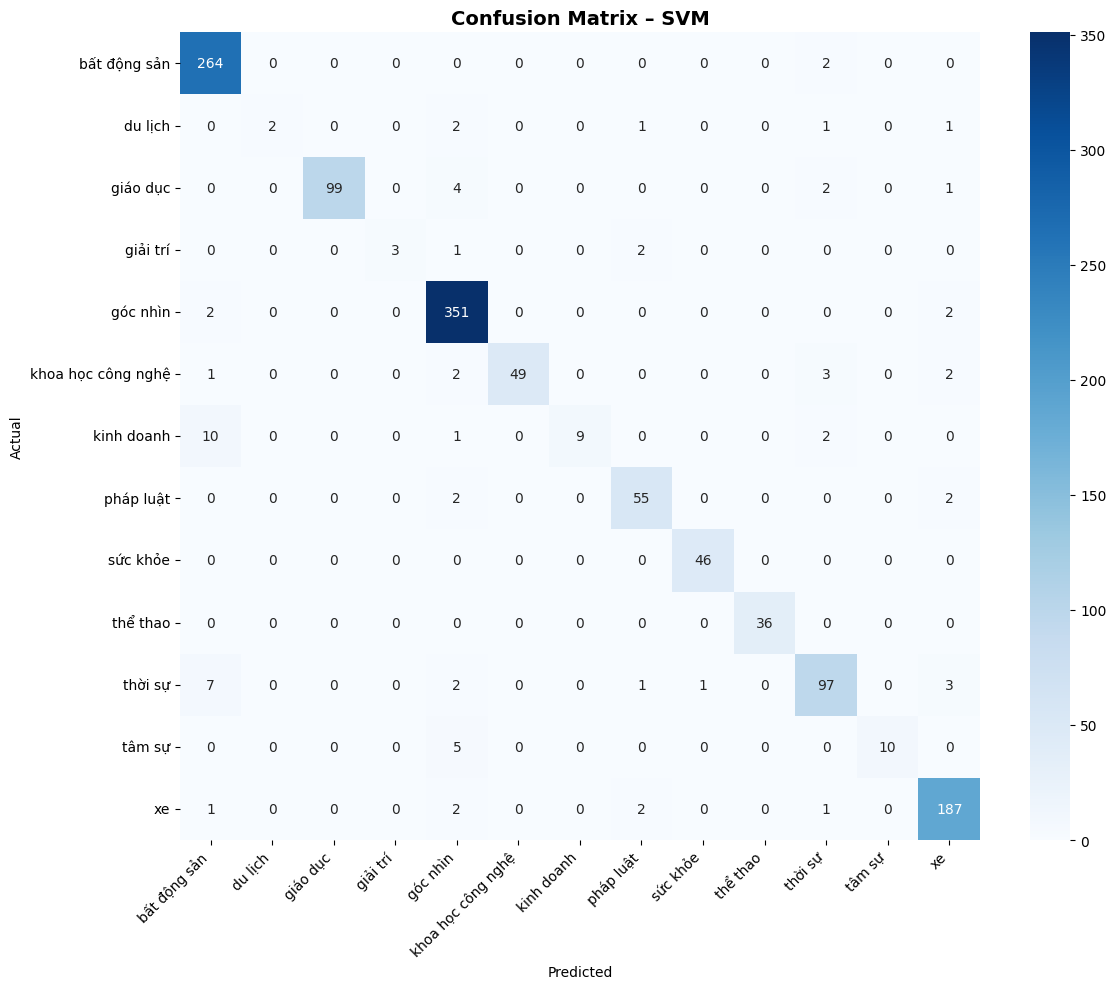

In [ ]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_, ax=ax
)
ax.set_title('Confusion Matrix – SVM', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
print('Chạy 5-fold Cross Validation...')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
print(f'CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Scores per fold: {cv_scores.round(4)}')

Chạy 5-fold Cross Validation...
CV Accuracy: 0.9479 ± 0.0032
Scores per fold: [0.9539 0.9468 0.9452 0.9452 0.9484]


## 9. Top features theo class (SVM Coefficients)

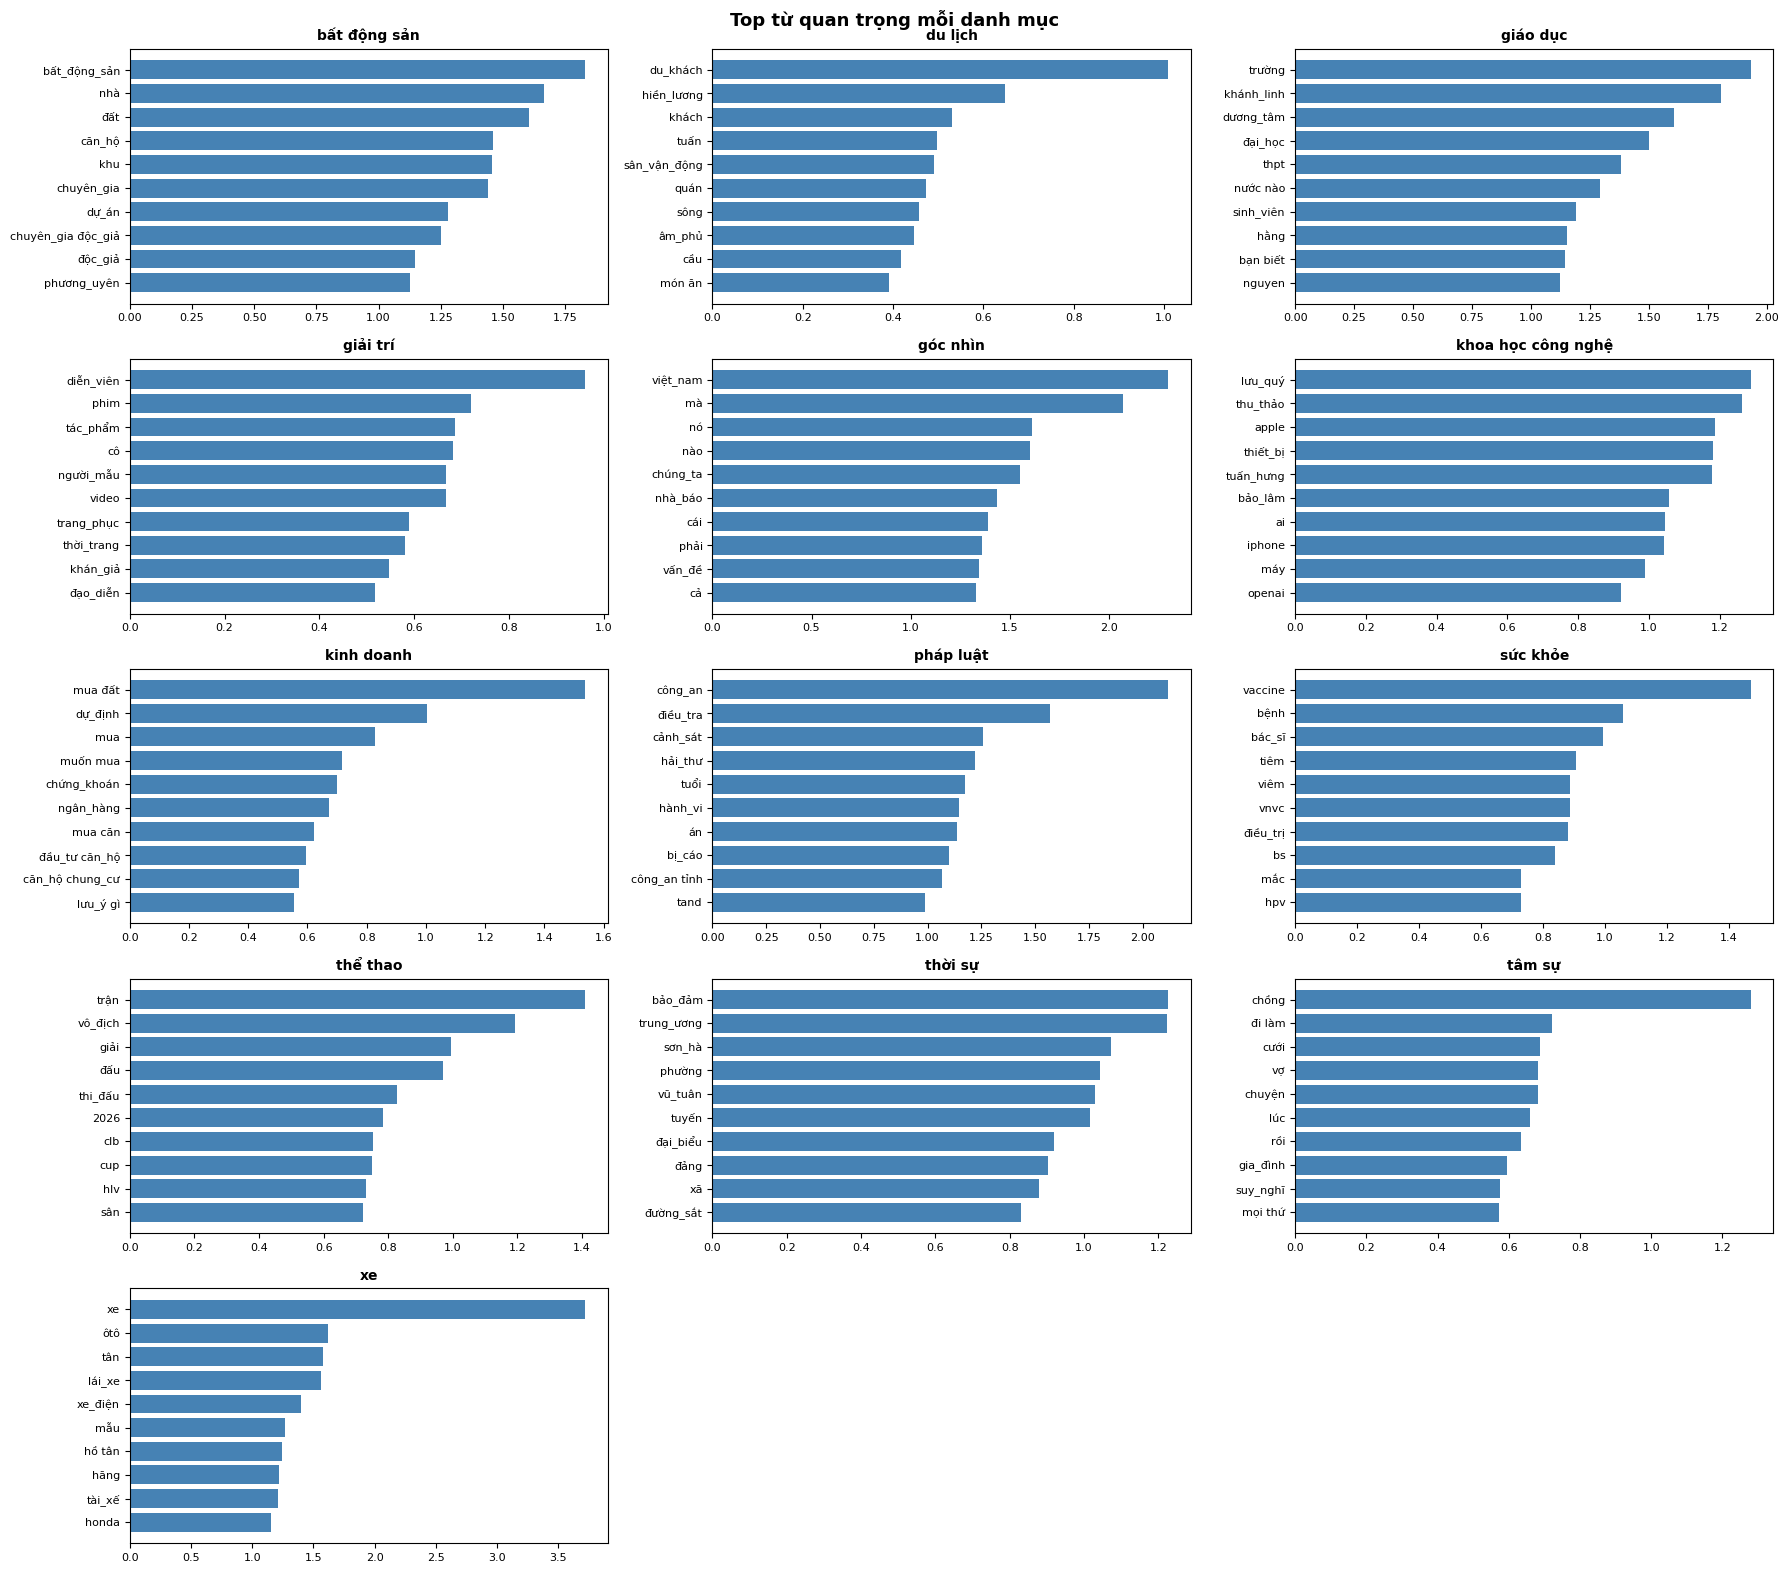

In [ ]:
tfidf_step = pipeline.named_steps['tfidf']
svm_step   = pipeline.named_steps['svm']
feature_names = np.array(tfidf_step.get_feature_names_out())

TOP_N   = 10
n_cls   = len(le.classes_)
ncols   = 3
nrows   = (n_cls + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 3 + 1))
axes = axes.flatten()

for i, class_name in enumerate(le.classes_):
    coef     = svm_step.coef_[i]
    top_idx  = np.argsort(coef)[-TOP_N:][::-1]
    axes[i].barh(feature_names[top_idx][::-1], coef[top_idx][::-1], color='steelblue')
    axes[i].set_title(class_name, fontweight='bold', fontsize=10)
    axes[i].tick_params(labelsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top từ quan trọng mỗi danh mục', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Thử predict bài mới

In [ ]:
def predict_article(text):
    cleaned = normalize_text(text)
    label   = pipeline.predict([cleaned])[0]
    return le.classes_[label]

samples = [
    'Giá đất Hà Nội tăng mạnh trong quý 4, nhiều nhà đầu tư quan tâm mua bán bất động sản',
    'Đội tuyển Việt Nam giành chiến thắng 3-0 trong trận đấu bóng đá tại vòng loại World Cup',
    'Học sinh lớp 12 chuẩn bị cho kỳ thi tốt nghiệp THPT quốc gia năm 2025',
    'Apple ra mắt chip M4 Ultra với hiệu năng AI vượt trội, cải tiến nhiều tính năng xử lý ngôn ngữ',
    'Bệnh viện Bạch Mai áp dụng phương pháp điều trị ung thư mới bằng liệu pháp miễn dịch'
]

for s in samples:
    cat = predict_article(s)
    print(f'[{cat:>25}] {s[:72]}')

[             bất động sản] Giá đất Hà Nội tăng mạnh trong quý 4, nhiều nhà đầu tư quan tâm mua bán 
[                 thể thao] Đội tuyển Việt Nam giành chiến thắng 3-0 trong trận đấu bóng đá tại vòng
[                 giáo dục] Học sinh lớp 12 chuẩn bị cho kỳ thi tốt nghiệp THPT quốc gia năm 2025
[       khoa học công nghệ] Apple ra mắt chip M4 Ultra với hiệu năng AI vượt trội, cải tiến nhiều tí
[                 sức khỏe] Bệnh viện Bạch Mai áp dụng phương pháp điều trị ung thư mới bằng liệu ph


## 11. Lưu model

In [ ]:
joblib.dump(pipeline, 'svm_pipeline.pkl')
joblib.dump(le,       'label_encoder.pkl')
print('Saved: svm_pipeline.pkl, label_encoder.pkl')

# Kiểm tra load lại
p2  = joblib.load('svm_pipeline.pkl')
le2 = joblib.load('label_encoder.pkl')
chk = le2.classes_[p2.predict([normalize_text(samples[0])])[0]]
print(f'Load OK → predict: {chk}')

Saved: svm_pipeline.pkl, label_encoder.pkl
Load OK → predict: bất động sản


## 12. Tóm tắt

In [ ]:
print('=' * 55)
print('       SUMMARY – SVM TEXT CLASSIFICATION')
print('=' * 55)
print(f'  Dataset      : {len(df)} bài, {len(le.classes_)} category')
print(f'  Tokenizer    : underthesea word_tokenize')
print(f'  Stopwords    : {len(VI_STOPWORDS)} từ')
print(f'  Features     : TF-IDF unigram+bigram, max 80k features')
print(f'  Model        : LinearSVC (C=1.0)')
print(f'  Accuracy     : {acc*100:.2f}%')
print(f'  F1 Macro     : {f1_macro:.4f}')
print(f'  F1 Weighted  : {f1_weight:.4f}')
print(f'  CV (5-fold)  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print('=' * 55)

       SUMMARY – SVM TEXT CLASSIFICATION
  Dataset      : 6391 bài, 13 category
  Tokenizer    : underthesea word_tokenize
  Stopwords    : 75 từ
  Features     : TF-IDF unigram+bigram, max 80k features
  Model        : LinearSVC (C=1.0)
  Accuracy     : 94.45%
  F1 Macro     : 0.8503
  F1 Weighted  : 0.9407
  CV (5-fold)  : 0.9479 ± 0.0032
